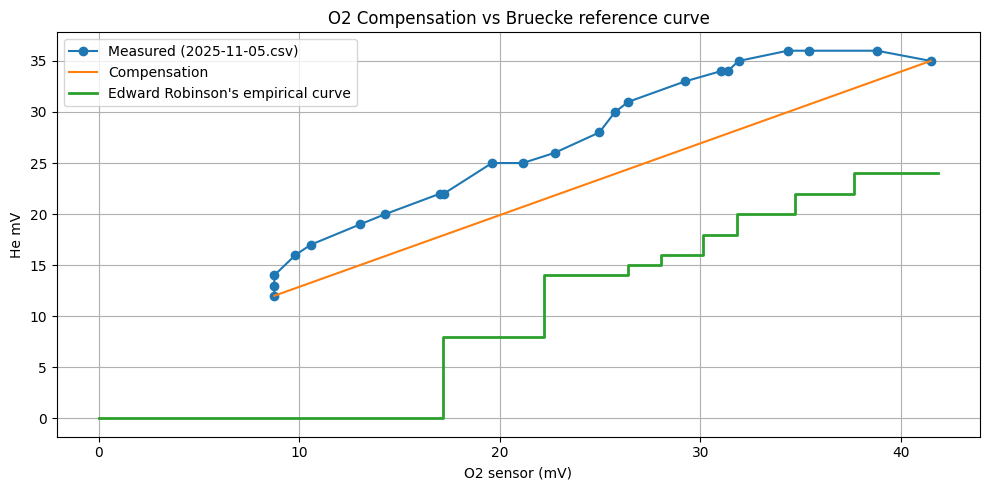

In [1]:
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

folder = r"data/o2_compensation"
files = sorted(glob.glob(os.path.join(folder, "*.csv")))

if not files:
    raise FileNotFoundError(f"No CSV files found in {folder}")

plt.figure(figsize=(10,5))

# Plot each file
for file in files:
    try:
        df = pd.read_csv(file, comment="#")
        assert {"o2_mv", "he_mv"}.issubset(df.columns)
    except Exception as e:
        print(f"Skipping file {file}: {e}")
        continue
    
    fname = os.path.basename(file)
    plt.plot(df["o2_mv"], df["he_mv"], label=f"Measured ({fname})", marker='o')

    # Calibrate by assuming that
    # - the first value in the series is air oxygen
    # - the last value in the series is 100% oxygen
    he_zero = df["he_mv"].values[0]
    o2_calib_21 = df["o2_mv"].values[0]
    o2_voltage = df["o2_mv"].values[-1]
    he_voltage = df["he_mv"].values[-1]

    o2_compensation_k = (he_voltage-he_zero)*o2_calib_21/(o2_voltage-o2_calib_21)
    o2_compensation = (df["o2_mv"]-o2_calib_21)/o2_calib_21*o2_compensation_k

    plt.plot(df["o2_mv"], o2_compensation+he_zero, label=f"Compensation")
    


# Compare to the empirical curve by Edward Robinson
def bruecke_from_nitrox(n):
    if n > 89: return 24
    elif n > 82: return 22
    elif n > 75: return 20
    elif n > 71: return 18
    elif n > 66: return 16
    elif n > 62: return 15
    elif n > 57: return 14
    elif n > 52: return 14
    elif n > 40: return 8
    else: return 0

nitrox = np.arange(0, 101, 1).astype(float)        # 0 → 100% O2
mv_est = nitrox / 20.9 * 8.75                     # convert to mV. Used my calibration values to get these on the same ballpark
bruecke_vals = np.array([bruecke_from_nitrox(n) for n in nitrox], dtype=float)

plt.step(mv_est, bruecke_vals, where='post', linewidth=2, label="Edward Robinson's empirical curve")

plt.title("O2 Compensation vs Bruecke reference curve")
plt.xlabel("O2 sensor (mV)")
plt.ylabel("He mV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion
It will be more simple to compensate by using raw o2_mv values instead of the calculated nitrox percentage. Linear estimate and calibration only with 100% helium is probably good enough solution to compensate.

In [2]:
print(f"Suggested default value o2_compensation_k = {o2_compensation_k:.0f}")

Suggested default value o2_compensation_k = 6
